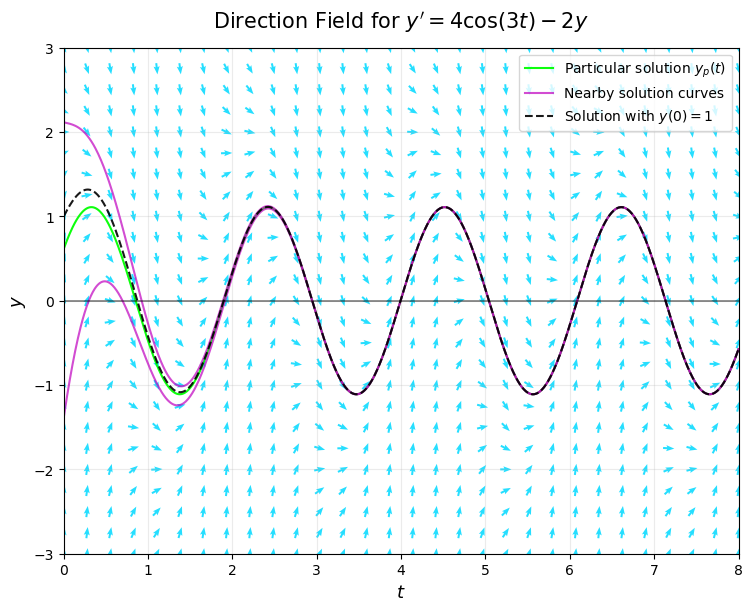

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------
# Direction field for
# dy/dt = 4 cos(3t) - 2y
# ---------------------------------------------------

# Grid
t = np.linspace(0, 8, 30)
y = np.linspace(-3, 3, 25)

T, Y = np.meshgrid(t, y)

# Differential equation
M = 4 * np.cos(3 * T) - 2 * Y

# Normalize vectors
L = np.sqrt(1 + M**2)

U = 1 / L
V = M / L

# ---------------------------------------------------
# Figure setup
# ---------------------------------------------------

fig, ax = plt.subplots(
    figsize = (8, 6),
    constrained_layout = True
)

# ---------------------------------------------------
# Direction field
# ---------------------------------------------------

ax.quiver(
    T, Y,
    U, V,
    color = '#00d9ff',
    angles = 'xy',
    scale_units = 'xy',
    scale = 7.5,
    width = 0.003,
    pivot = 'middle',
    headwidth = 3,
    headlength = 4,
    headaxislength = 3.5,
    alpha = 0.85
)

# ---------------------------------------------------
# Time values for solution curves
# ---------------------------------------------------

t_curve = np.linspace(0, 8, 1000)

# ---------------------------------------------------
# Particular solution
# ---------------------------------------------------

y_p = (
    (8/13) * np.cos(3 * t_curve)
    +
    (12/13) * np.sin(3 * t_curve)
)

ax.plot(
    t_curve,
    y_p,
    color = 'lime',
    linewidth = 1.5,
    alpha = 0.95,
    label = r"Particular solution $y_p(t)$"
)

# ---------------------------------------------------
# Nearby solutions
# y = y_p + c e^{-2t}
# ---------------------------------------------------

constants = [-2, 1.5]

for i, c in enumerate(constants):

    y_curve = y_p + c * np.exp(-2 * t_curve)

    ax.plot(
        t_curve,
        y_curve,
        color = 'm',
        linewidth = 1.5,
        alpha = 0.7,
        label = "Nearby solution curves" if i == 0 else None
    )

# ---------------------------------------------------
# IVP solution
# ---------------------------------------------------

y_ivp = y_p + (5/13) * np.exp(-2 * t_curve)

ax.plot(
    t_curve,
    y_ivp,
    color = 'black',
    linewidth = 1.5,
    linestyle = '--',
    alpha = 0.9,
    label = r"Solution with $y(0)=1$"
)

# ---------------------------------------------------
# Axes
# ---------------------------------------------------

ax.axhline(0, color = 'black', linewidth = 1.1, alpha = 0.55)
ax.axvline(0, color = 'black', linewidth = 1.1, alpha = 0.55)

# ---------------------------------------------------
# Labels and title
# ---------------------------------------------------

ax.set_xlabel(r"$t$", fontsize = 13)
ax.set_ylabel(r"$y$", fontsize = 13)

ax.set_title(
    r"Direction Field for $ y' = 4\cos(3t) - 2y $",
    fontsize = 15,
    pad = 14
)

# ---------------------------------------------------
# Limits
# ---------------------------------------------------

ax.set_xlim(0, 8)
ax.set_ylim(-3, 3)

# Equal aspect ratio prevents geometric distortion
# between the field and solution curves.
ax.set_aspect('equal', adjustable = 'box')

# ---------------------------------------------------
# Grid
# ---------------------------------------------------

ax.grid(
    True,
    alpha = 0.25,
    linewidth = 0.8
)

# ---------------------------------------------------
# Legend
# ---------------------------------------------------

ax.legend(
    fontsize = 10,
    loc = 'upper right'
)

plt.show()